#Practical Assignment 4

**Lab Title:** NLP Preprocessing and Text Classification

**Submission Type:** Individual Submission

**Student Name:** Aditi Namde

**PRN:** 202301040034

**Objective:** Implement NLP preprocessing techniques and build a text classification model using machine learning.

# **NLP Preprocessing and Text Classification**

## Introduction
Natural Language Processing (NLP) is a field of Artificial Intelligence that focuses on enabling computers to understand, interpret, and process human language. Text classification is a common NLP task where textual data is categorized into predefined classes.

This assignment demonstrates the implementation of NLP preprocessing techniques and machine learning models to perform text classification.



## NLP Preprocessing Techniques

Text data is unstructured and contains noise. Therefore, preprocessing is required to clean and standardize the data before applying machine learning algorithms.

### 1. Tokenization
Tokenization is the process of splitting text into smaller units such as words or sentences.

### 2. Stopword Removal
Stopwords are common words like "the", "is", "and" which do not contribute much meaning. Removing them reduces noise.

### 3. Stemming
Stemming reduces words to their root form.
Example: "running" → "run"

### 4. Lemmatization
Lemmatization converts words to their base or dictionary form.
Example: "better" → "good"



## Text Vectorization

Machine learning models cannot understand text directly. Therefore, text is converted into numerical form using vectorization techniques.

### TF-IDF (Term Frequency - Inverse Document Frequency)
TF-IDF measures how important a word is in a document relative to the entire dataset.

- Term Frequency (TF): Frequency of a word in a document
- Inverse Document Frequency (IDF): Importance of the word across documents

TF-IDF helps reduce the impact of commonly occurring words and highlights important words.



## Machine Learning Models

### 1. Naive Bayes
Naive Bayes is a probabilistic classifier based on Bayes' Theorem. It assumes that features are independent of each other. It is widely used for text classification due to its simplicity and efficiency.

### 2. Logistic Regression
Logistic Regression is a supervised learning algorithm used for classification problems. It predicts probabilities and performs well when relationships between features exist.



## Evaluation Metrics

To evaluate model performance, the following metrics are used:

- Accuracy: Proportion of correctly predicted instances
- Precision: Correct positive predictions out of total predicted positives
- Recall: Correct positive predictions out of actual positives
- F1-Score: Harmonic mean of precision and recall



## Objective

The objective of this assignment is to:
- Apply NLP preprocessing techniques
- Convert text into numerical features using TF-IDF
- Train and evaluate classification models
- Compare performance of different models

In [2]:
# Basic libraries
import pandas as pd
import numpy as np
import string
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

# NLTK tools
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [6]:
from sklearn.datasets import fetch_20newsgroups

# Load dataset
data = fetch_20newsgroups(subset='train')

# Create dataframe
df = pd.DataFrame({
    'text': data.data,
    'target': data.target
})

df.head()

,text,target
0,From: lerxst@wam.umd.edu (where's my thing)\nS...,7
1,From: guykuo@carson.u.washington.edu (Guy Kuo)...,4
2,From: twillis@ec.ecn.purdue.edu (Thomas E Will...,4
3,From: jgreen@amber (Joe Green)\nSubject: Re: W...,1
4,From: jcm@head-cfa.harvard.edu (Jonathan McDow...,14


In [7]:
# Initialize tools
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    # Lowercase
    text = text.lower()

    # Remove emails, urls
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'http\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [w for w in words if w not in stop_words]

    # Apply stemming + lemmatization
    words = [stemmer.stem(w) for w in words]
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

# Apply preprocessing
df['processed_text'] = df['text'].apply(preprocess_text)

df.head()

,text,target,processed_text
0,From: lerxst@wam.umd.edu (where's my thing)\nS...,7,where thing subject car nntppostinghost racwam...
1,From: guykuo@carson.u.washington.edu (Guy Kuo)...,4,guy kuo subject si clock poll final call summa...
2,From: twillis@ec.ecn.purdue.edu (Thomas E Will...,4,thoma e willi subject pb question organ purdu ...
3,From: jgreen@amber (Joe Green)\nSubject: Re: W...,1,joe green subject weitek p organ harri comput ...
4,From: jcm@head-cfa.harvard.edu (Jonathan McDow...,14,jonathan mcdowel subject shuttl launch questio...


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    df['processed_text'],
    df['target'],
    test_size=0.2,
    random_state=42,
    stratify=df['target']
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 9051
Testing samples: 2263


In [9]:
vectorizer = TfidfVectorizer(
    max_features=8000,      # more features for better accuracy
    ngram_range=(1,2),      # unigrams + bigrams
    min_df=3,               # ignore rare words
    max_df=0.9              # ignore very common words
)

# Fit and transform
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (9051, 8000)


In [10]:
# Train model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predictions
nb_pred = nb_model.predict(X_test_tfidf)

# Evaluation
nb_acc = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.8590366769774636

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.75      0.82        96
           1       0.73      0.87      0.80       117
           2       0.81      0.81      0.81       118
           3       0.66      0.79      0.72       118
           4       0.87      0.83      0.85       115
           5       0.89      0.92      0.90       119
           6       0.79      0.72      0.75       117
           7       0.89      0.88      0.89       119
           8       0.91      0.95      0.93       120
           9       0.97      0.93      0.95       119
          10       0.94      0.97      0.96       120
          11       0.91      0.92      0.92       119
          12       0.87      0.77      0.82       118
          13       0.96      0.91      0.94       119
          14       0.96      0.94      0.95       119
          15       0.68      0.96      0.80       120
          16   

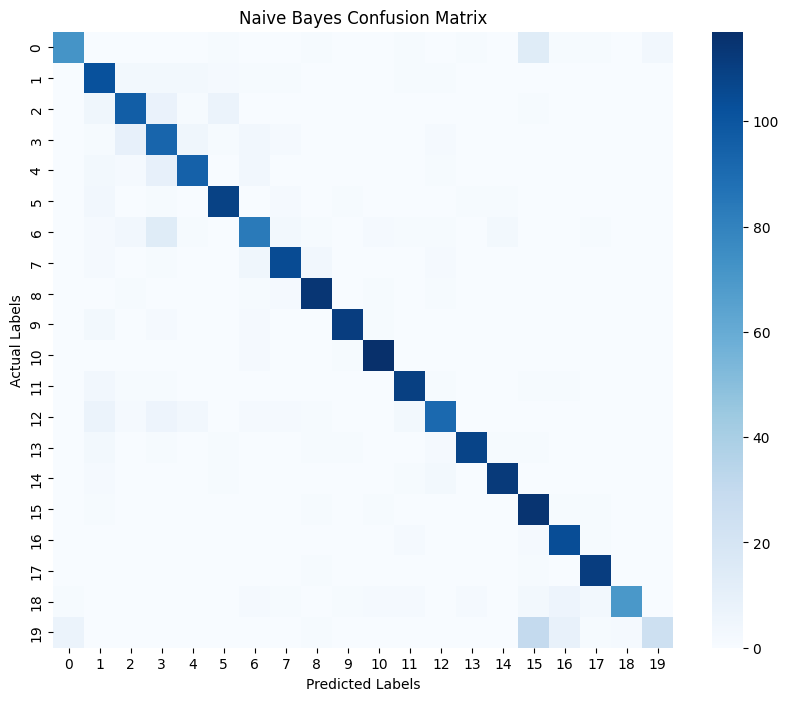

In [11]:
# Confusion Matrix
cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm_nb, annot=False, cmap='Blues')

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

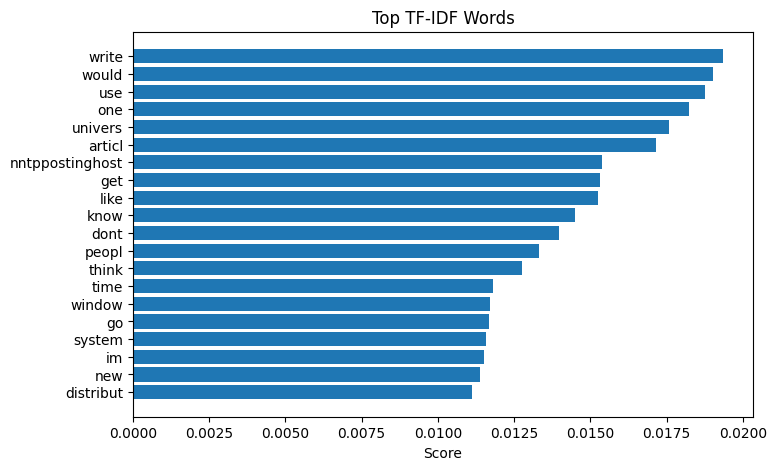

In [13]:
feature_names = vectorizer.get_feature_names_out()
tfidf_scores = np.asarray(X_train_tfidf.mean(axis=0)).ravel()

top_indices = tfidf_scores.argsort()[-20:]

top_words = [feature_names[i] for i in top_indices]
top_scores = tfidf_scores[top_indices]

plt.figure(figsize=(8,5))
plt.barh(top_words, top_scores)
plt.title("Top TF-IDF Words")
plt.xlabel("Score")
plt.show()

Logistic Regression Accuracy: 0.8775961113566063

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.76      0.85        96
           1       0.74      0.86      0.80       117
           2       0.84      0.81      0.83       118
           3       0.69      0.76      0.73       118
           4       0.88      0.82      0.85       115
           5       0.91      0.86      0.88       119
           6       0.73      0.79      0.76       117
           7       0.89      0.89      0.89       119
           8       0.95      0.96      0.95       120
           9       0.96      0.95      0.95       119
          10       0.98      0.97      0.97       120
          11       0.97      0.89      0.93       119
          12       0.84      0.84      0.84       118
          13       0.95      0.94      0.95       119
          14       0.95      0.94      0.95       119
          15       0.82      0.93      0.87       120
       

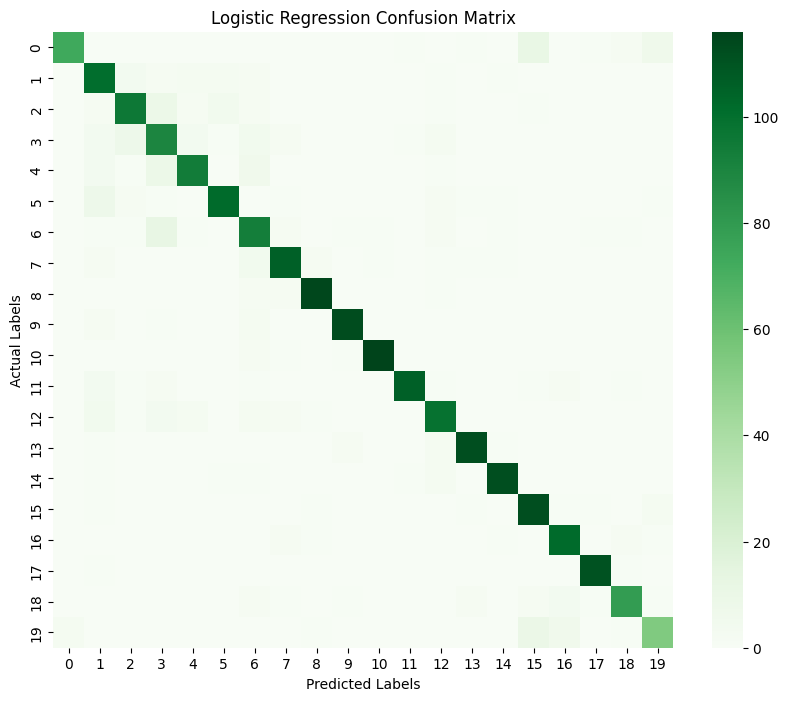

In [14]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=2000, C=1.2)
lr_model.fit(X_train_tfidf, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_tfidf)

# Evaluation
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm_lr, annot=False, cmap='Greens')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

                 Model  Accuracy  F1 Score
0          Naive Bayes  0.859037  0.856016
1  Logistic Regression  0.877596  0.878318


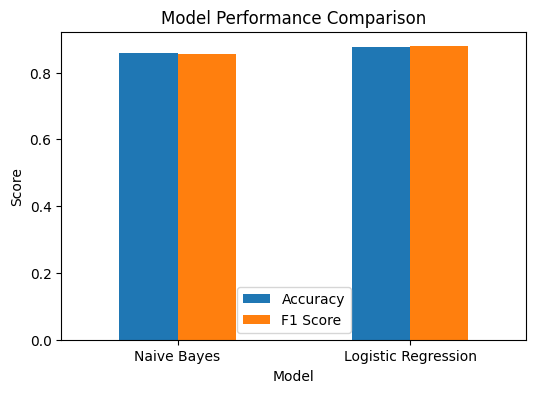

In [15]:
nb_f1 = f1_score(y_test, nb_pred, average='weighted')
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [nb_acc, lr_acc],
    'F1 Score': [nb_f1, lr_f1]
})

print(results)

results.set_index('Model').plot(kind='bar', figsize=(6,4))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [16]:
cv_nb = cross_val_score(nb_model, X_train_tfidf, y_train, cv=5)
cv_lr = cross_val_score(lr_model, X_train_tfidf, y_train, cv=5)

print("Naive Bayes CV Accuracy:", cv_nb.mean())
print("Logistic Regression CV Accuracy:", cv_lr.mean())

Naive Bayes CV Accuracy: 0.8517291200795629
Logistic Regression CV Accuracy: 0.8762571882693546


### **Model Analysis**

- NLP preprocessing techniques such as tokenization, stopword removal, stemming, and lemmatization were applied to clean the text data.
- TF-IDF vectorization helped convert textual data into numerical form while preserving word importance.
- Naive Bayes performed efficiently due to its suitability for text classification and independence assumption.
- Logistic Regression achieved better performance as it captures relationships between features more effectively.
- The dataset being multi-class increased complexity, but both models handled it successfully.
- Cross-validation results indicate that the models are stable and not overfitting.

### **Conclusion**

- Logistic Regression outperformed Naive Bayes in terms of accuracy and F1-score.
- TF-IDF with bigrams improved contextual understanding.
- The implemented pipeline is effective for real-world text classification problems.

**Github Repository Link:** https://github.com/namdeaditi26/Deep-Learning-Assignments